In [1]:
import json
import os
import urllib

import folium
import geemap.foliumap as geemap
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import rasterio
import requests
import rioxarray
import seaborn
import xarray as xr
from geotessera import GeoTessera
from helpers.simplecube import load_xarray, save_xarray, simple_cube
from helpers.simplecube_helpers import *
from helpers.tessera_helpers import *
from pyproj import Transformer
from rasterio.features import rasterize
from rasterio.transform import Affine
from scipy.signal import savgol_filter
from shapely import wkt
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, RobustScaler

WGS84_WKT = WGS84_WKT

## Extract and build mosaics

In [3]:
# gt = GeoTessera()

year = 2024

test_tile_path = "./dataset/test_tile/"
roi_tile_path = "./dataset/roi_tiles/"
samples_path = "./dataset/samples/"

RASTERS_PATH = "./dataset/rasters"
os.makedirs(RASTERS_PATH, exist_ok=True)

[-61.25000000000001, -8.25, -61.0, -7.999999999999998]


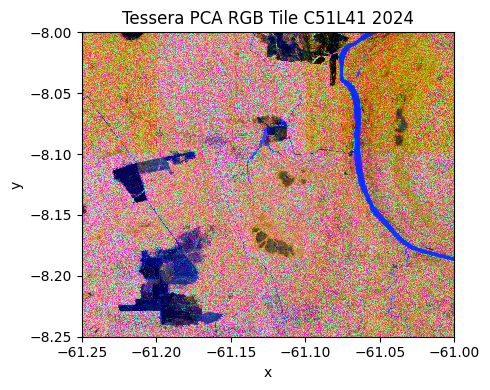

[-61.25000000000001, -10.000000000000002, -61.0, -9.749999999999998]


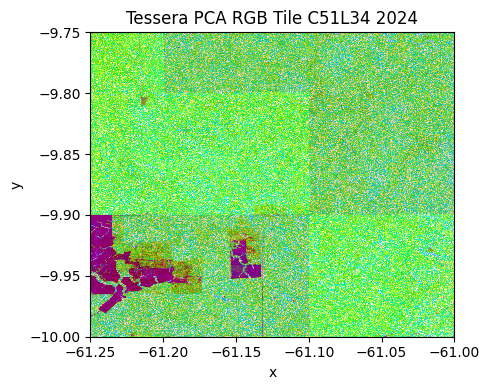

[-59.00000000000001, -2.75, -58.75, -2.5]


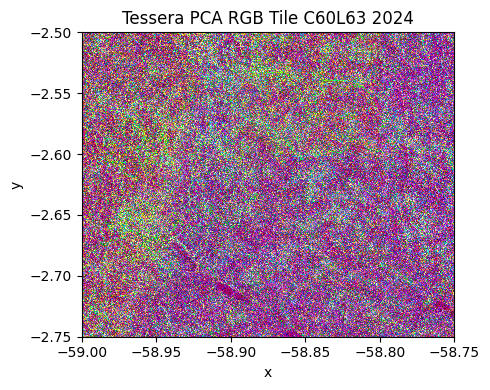

In [4]:
# # ============================= Roi test
test_tile = gpd.read_file(f"{test_tile_path}tile_C51L41_WGS84.gpkg")
if test_tile.crs != "EPSG:4326":
    test_tile = test_tile.to_crs(epsg=4326)
# min_lon, min_lat, max_lon, max_lat = test_tile.total_bounds
# center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
test_tile_bbox = list([ float(b) for b in test_tile.total_bounds ])
print(test_tile_bbox)

bbox = test_tile_bbox
tile = test_tile

output_path_emb_raster = f"{RASTERS_PATH}/tessera_{year}_{tile.iloc[0].id}.tif"

# tiles_to_fetch = gt.fetch_mosaic_for_region(bbox = bbox, year = year, target_crs = tile.crs)
# tessera_mosaic_embeddings = create_tessera_mosaic(gt, year, bbox)

# # Salva diretamente em GeoTIFF com compressão LZW para otimizar espaço
# tessera_mosaic_embeddings.rio.to_raster(
#     output_path_emb_raster,
#     driver="GTiff",
#     dtype="float32",
#     nodata=np.nan,
#     compress="lzw",  # Reduz o tamanho do arquivo sem perda de qualidade
#     tiled=True,
# )
# # Faz a leitura do arquivo salvo
tessera_mosaic_test = rioxarray.open_rasterio(output_path_emb_raster, masked=True)
# tessera_mosaic_test_pca_rgb = compute_pca_rgb(tessera_mosaic_test)
# tessera_mosaic_test_pca_rgb.rio.to_raster(f"{output_path_emb_raster[:-4]}_pca.tif", compress="lzw")
tessera_mosaic_test_pca_rgb = rioxarray.open_rasterio(f"{output_path_emb_raster[:-4]}_pca.tif", masked=True)

plot_xarray_(
    tessera_mosaic_test_pca_rgb,
    title=f"Tessera PCA RGB Tile {tile.iloc[0].id} {year}",
    figsize=(5, 4)
)

# ============================= Roi 1
roi_tile_1 = gpd.read_file(f"{roi_tile_path}/tile_C51L34_Eco03_WGS84.gpkg")
if roi_tile_1.crs != "EPSG:4326":
    roi_tile_1 = roi_tile_1.to_crs(epsg=4326)
roi_tile_1_bbox = list([ float(b) for b in roi_tile_1.total_bounds ])
print(roi_tile_1_bbox)

bbox = roi_tile_1_bbox
tile = roi_tile_1

output_path_emb_raster = f"{RASTERS_PATH}/tessera_{year}_{tile.iloc[0].id}.tif"

# tiles_to_fetch = gt.fetch_mosaic_for_region(bbox = bbox, year = year, target_crs = tile.crs)
# tessera_mosaic_embeddings = create_tessera_mosaic(gt, year, bbox)

# # Salva diretamente em GeoTIFF com compressão LZW para otimizar espaço
# tessera_mosaic_embeddings.rio.to_raster(
#     output_path_emb_raster,
#     driver="GTiff",
#     dtype="float32",
#     nodata=np.nan,
#     compress="lzw",  # Reduz o tamanho do arquivo sem perda de qualidade
#     tiled=True,
# )
# # Faz a leitura do arquivo salvo
tessera_mosaic_roi_tile_1 = rioxarray.open_rasterio(output_path_emb_raster, masked=True)
# tessera_mosaic_roi_tile_1_pca_rgb = compute_pca_rgb(tessera_mosaic_roi_tile_1)
# tessera_mosaic_roi_tile_1_pca_rgb.rio.to_raster(f"{output_path_emb_raster[:-4]}_pca.tif", compress="lzw")
tessera_mosaic_roi_tile_1_pca_rgb = rioxarray.open_rasterio(f"{output_path_emb_raster[:-4]}_pca.tif", masked=True)

plot_xarray_(
    tessera_mosaic_roi_tile_1_pca_rgb,
    title=f"Tessera PCA RGB Tile {tile.iloc[0].id} {year}",
    figsize=(5, 4)
)

# ============================= Roi 2
roi_tile_2 = gpd.read_file(f"{roi_tile_path}/tile_C60L63_Eco01_WGS84.gpkg")
if roi_tile_2.crs != "EPSG:4326":
    roi_tile_2 = roi_tile_2.to_crs(epsg=4326)
roi_tile_2_bbox = list([ float(b) for b in roi_tile_2.total_bounds ])
print(roi_tile_2_bbox)

bbox = roi_tile_2_bbox
tile = roi_tile_2

output_path_emb_raster = f"{RASTERS_PATH}/tessera_{year}_{tile.iloc[0].id}.tif"

# tiles_to_fetch = gt.fetch_mosaic_for_region(bbox = bbox, year = year, target_crs = tile.crs)
# tessera_mosaic_embeddings = create_tessera_mosaic(gt, year, bbox)
# #  Aplica correções e normalização com base em tiles selecionados
# corrections = [
#     # 1. Bloco superior
#     {"target": (-58.90, -2.60, -58.80, -2.50), "ref": (-58.98, -2.60, -58.90, -2.50)},
#     # 2. Bloco inferior direito
#     {"target": (-58.80, -2.80, -58.70, -2.70), "ref": (-58.90, -2.80, -58.80, -2.70)}
# ]
# tessera_mosaic_embeddings = harmonize_by_tile_embeddings(tessera_mosaic_embeddings, corrections)
# # Salva diretamente em GeoTIFF com compressão LZW para otimizar espaço
# tessera_mosaic_embeddings.rio.to_raster(
#     output_path_emb_raster,
#     driver="GTiff",
#     dtype="float32",
#     nodata=np.nan,
#     compress="lzw",  # Reduz o tamanho do arquivo sem perda de qualidade
#     tiled=True,
# )
# Faz a leitura do arquivo salvo
tessera_mosaic_roi_tile_2 = rioxarray.open_rasterio(output_path_emb_raster, masked=True)
# tessera_mosaic_roi_tile_2_pca_rgb = compute_pca_rgb(tessera_mosaic_roi_tile_2)
# tessera_mosaic_roi_tile_2_pca_rgb.rio.to_raster(f"{output_path_emb_raster[:-4]}_pca.tif", compress="lzw")
tessera_mosaic_roi_tile_2_pca_rgb = rioxarray.open_rasterio(f"{output_path_emb_raster[:-4]}_pca.tif", masked=True)

plot_xarray_(
    tessera_mosaic_roi_tile_2_pca_rgb,
    title=f"Tessera PCA RGB Tile {tile.iloc[0].id} {year}",
    figsize=(5, 4)
)

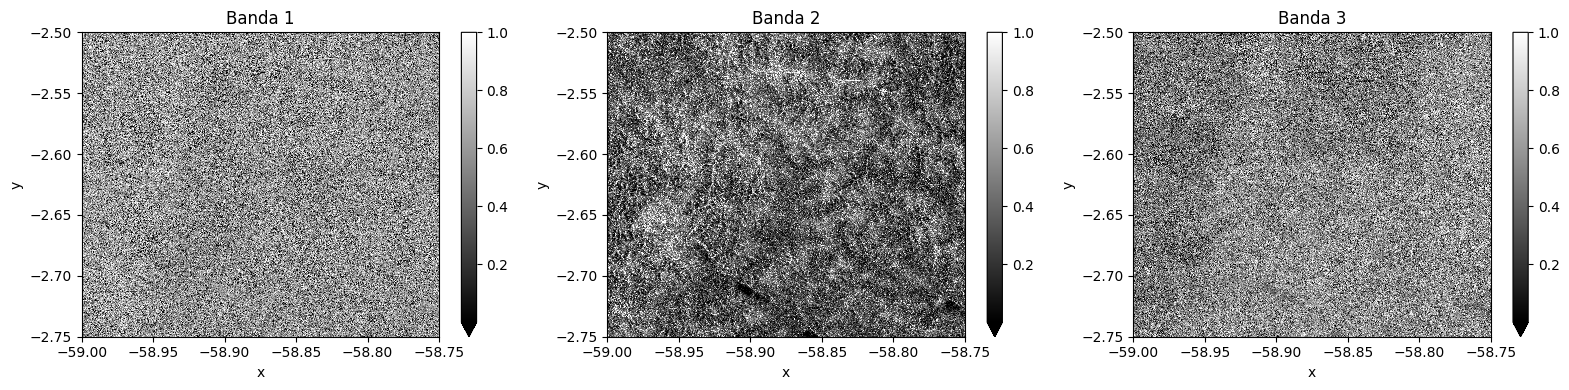

In [7]:
# Plota a média ou bandas individuais para encontrar os blocos artificiais
validate_mosaic_pca(tessera_mosaic_roi_tile_2_pca_rgb)

## Extract data from samples

In [35]:
# ============================= Roi test
tessera_mosaic = tessera_mosaic_test
tile = test_tile
tile_id = tile.iloc[0].id
samples_test_tile = gpd.read_file(f"{samples_path}samples_{tile_id}_{year}_points.csv")

samples = samples_test_tile
samples["geometry"] = samples["geometry"].apply(wkt.loads)
samples = gpd.GeoDataFrame(samples, geometry="geometry", crs="EPSG:4326")

df_final = extract_tessera_samples(
    tessera_mosaic = tessera_mosaic,
    samples = samples,
    year = 2024,
    label_column = "label"
)

output_csv = f"{samples_path}samples_{tile_id}_{year}_embeddings_tessera_pixel.csv"
df_final.to_csv(output_csv, index=False)

samples_test_tile = df_final.copy()

# ============================= Roi 1
tessera_mosaic = tessera_mosaic_roi_tile_1
tile = roi_tile_1
tile_id = tile.iloc[0].id
samples_roi_tile_1 = gpd.read_file(f"{samples_path}samples_{tile.iloc[0].id}_{year}_points.csv")

samples = samples_roi_tile_1
samples["geometry"] = samples["geometry"].apply(wkt.loads)
samples = gpd.GeoDataFrame(samples, geometry="geometry", crs="EPSG:4326")

df_final = extract_tessera_samples(
    tessera_mosaic = tessera_mosaic,
    samples = samples,
    year = 2024,
    label_column = "label"
)

output_csv = f"{samples_path}samples_{tile_id}_{year}_embeddings_tessera_pixel.csv"
df_final.to_csv(output_csv, index=False)

samples_roi_tile_1 = df_final.copy()

# ============================= Roi 2
tessera_mosaic = tessera_mosaic_roi_tile_2
tile = roi_tile_2
tile_id = tile.iloc[0].id
samples_roi_tile_2 = gpd.read_file(f"{samples_path}samples_{tile.iloc[0].id}_{year}_points.csv")

samples = samples_roi_tile_2
samples["geometry"] = samples["geometry"].apply(wkt.loads)
samples = gpd.GeoDataFrame(samples, geometry="geometry", crs="EPSG:4326")

df_final = extract_tessera_samples(
    tessera_mosaic = tessera_mosaic,
    samples = samples,
    year = 2024,
    label_column = "label"
)

output_csv = f"{samples_path}samples_{tile_id}_{year}_embeddings_tessera_pixel.csv"
df_final.to_csv(output_csv, index=False)

samples_roi_tile_2 = df_final.copy()

/tmp/ipykernel_25836/3704500643.py:111: UserWarning: Geometry column does not contain geometry.
  gdf_joined["geometry"] = gdf_joined.geometry.to_wkt()


Total de amostras Tessera extraídas: 8672


/tmp/ipykernel_25836/3704500643.py:111: UserWarning: Geometry column does not contain geometry.
  gdf_joined["geometry"] = gdf_joined.geometry.to_wkt()


Total de amostras Tessera extraídas: 2816


/tmp/ipykernel_25836/3704500643.py:111: UserWarning: Geometry column does not contain geometry.
  gdf_joined["geometry"] = gdf_joined.geometry.to_wkt()


Total de amostras Tessera extraídas: 5319


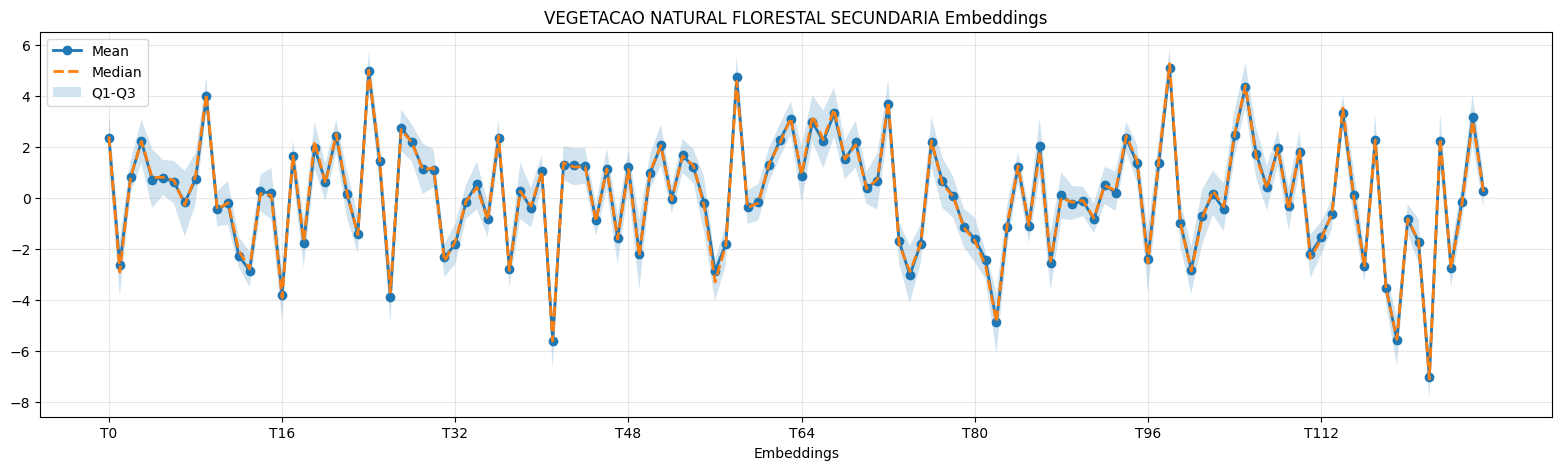

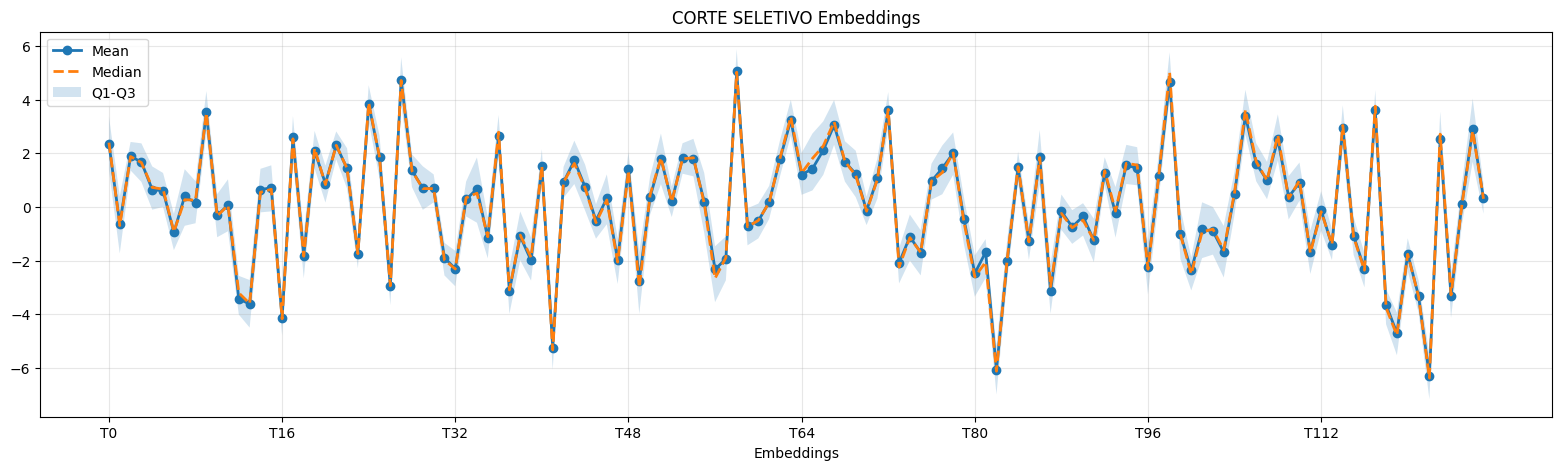

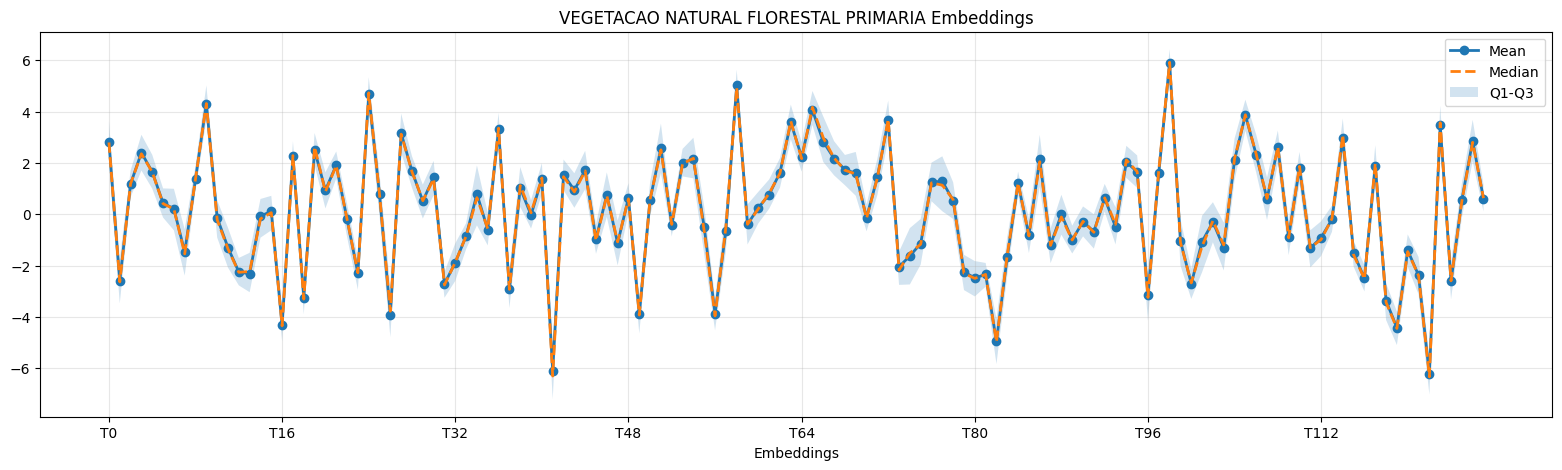

In [36]:
samples_embeddings = samples_test_tile.copy()
labels = set(samples_embeddings["label"])
column_names = [f"T{i}" for i in range(128)]
for label in labels:
    data_ = samples_embeddings[samples_embeddings["label"] == label]
    generatePlotFigPatterns(data_[column_names], label)

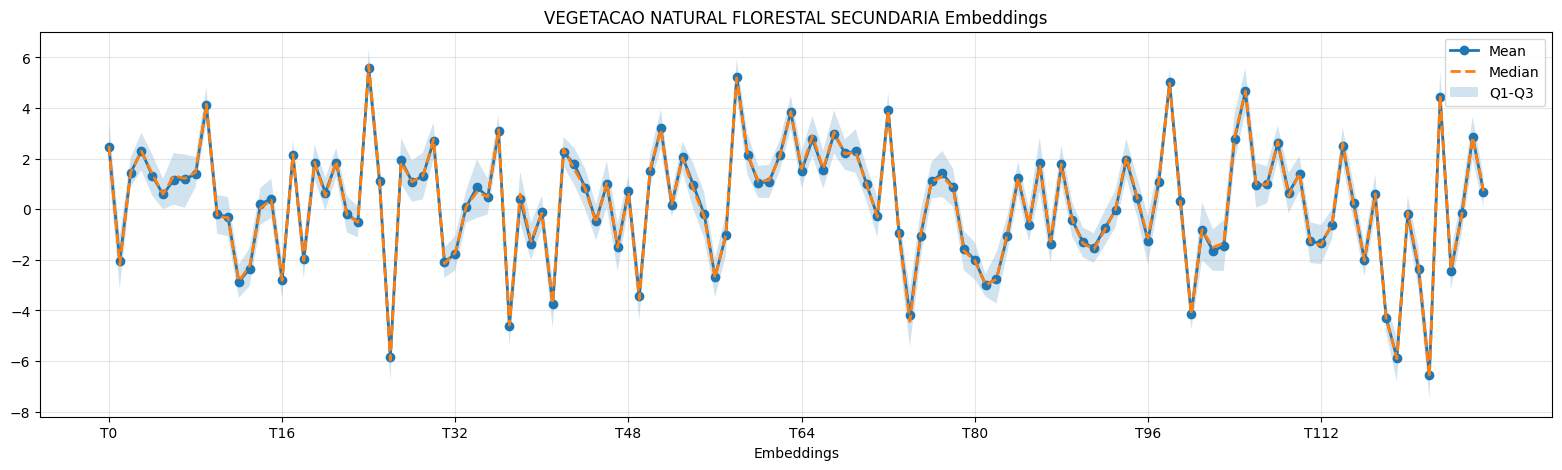

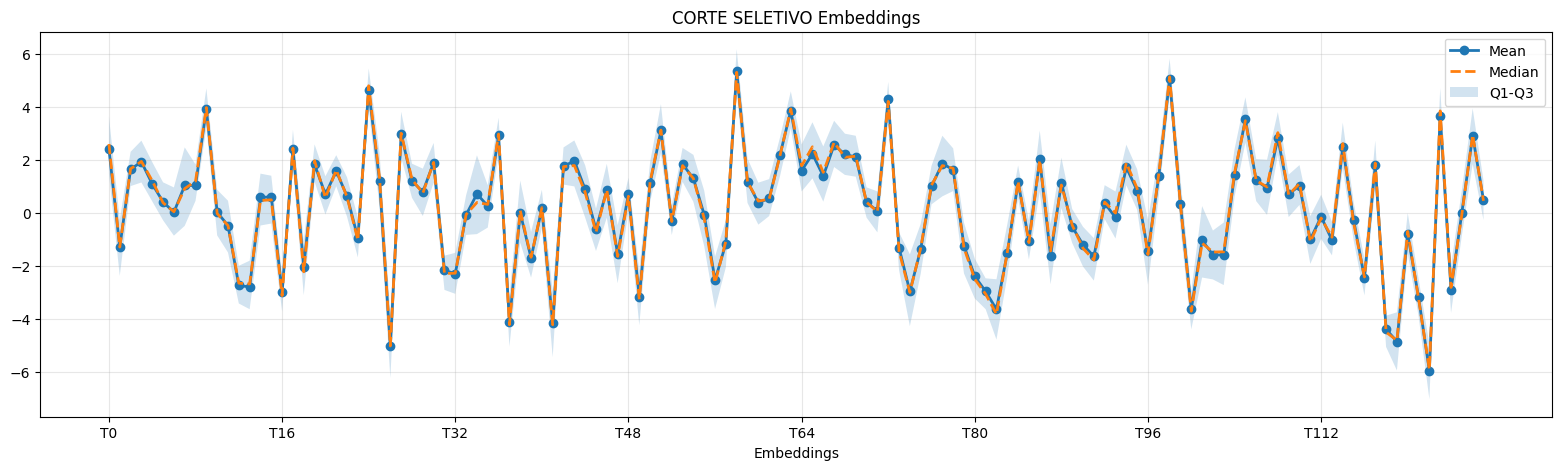

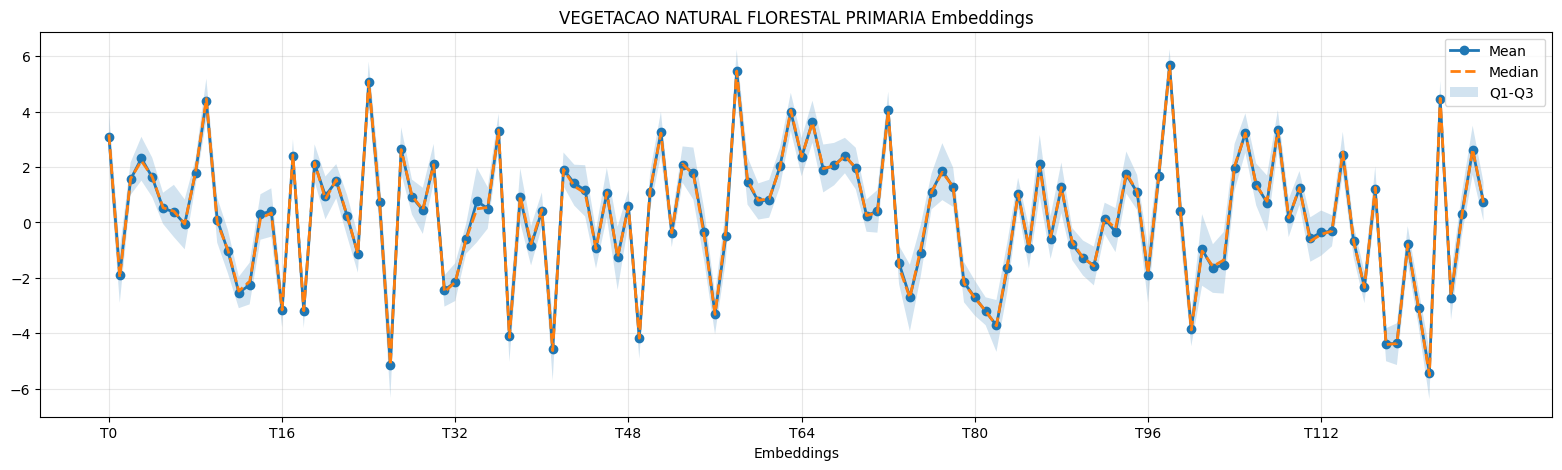

In [37]:
samples_embeddings = samples_roi_tile_1.copy()
labels = set(samples_embeddings["label"])
column_names = [f"T{i}" for i in range(128)]
for label in labels:
    data_ = samples_embeddings[samples_embeddings["label"] == label]
    generatePlotFigPatterns(data_[column_names], label)

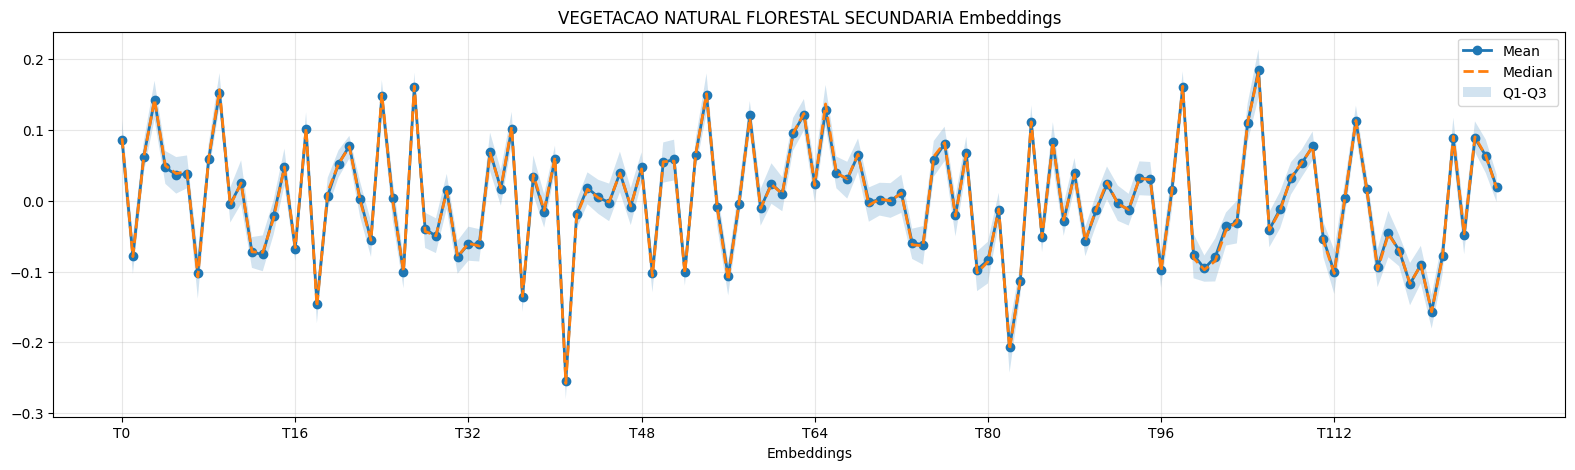

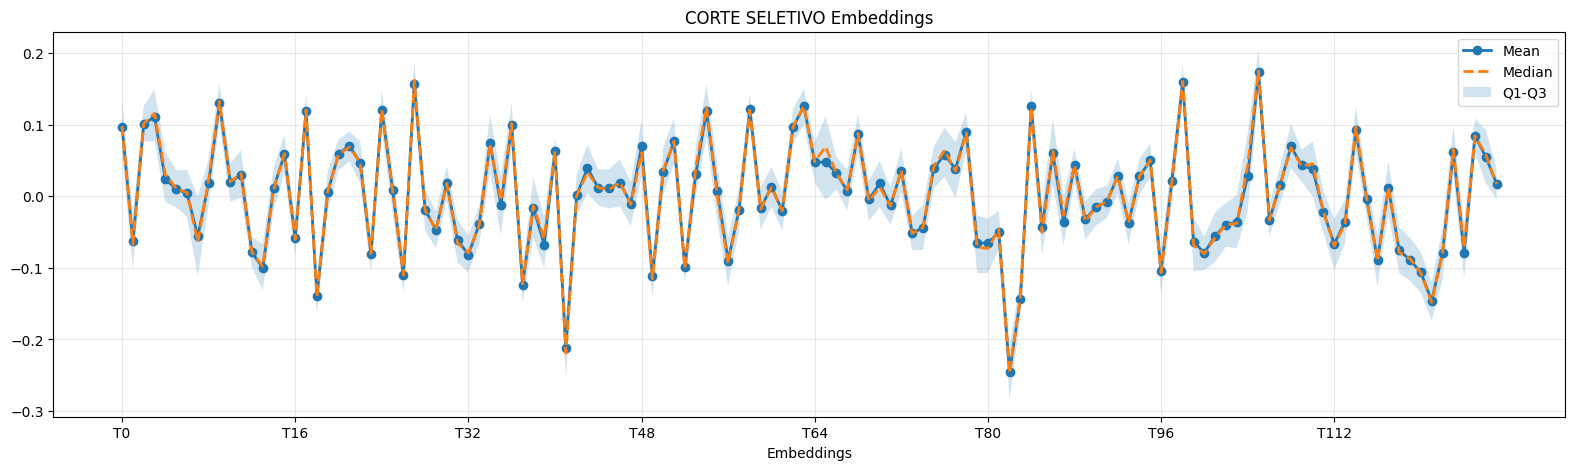

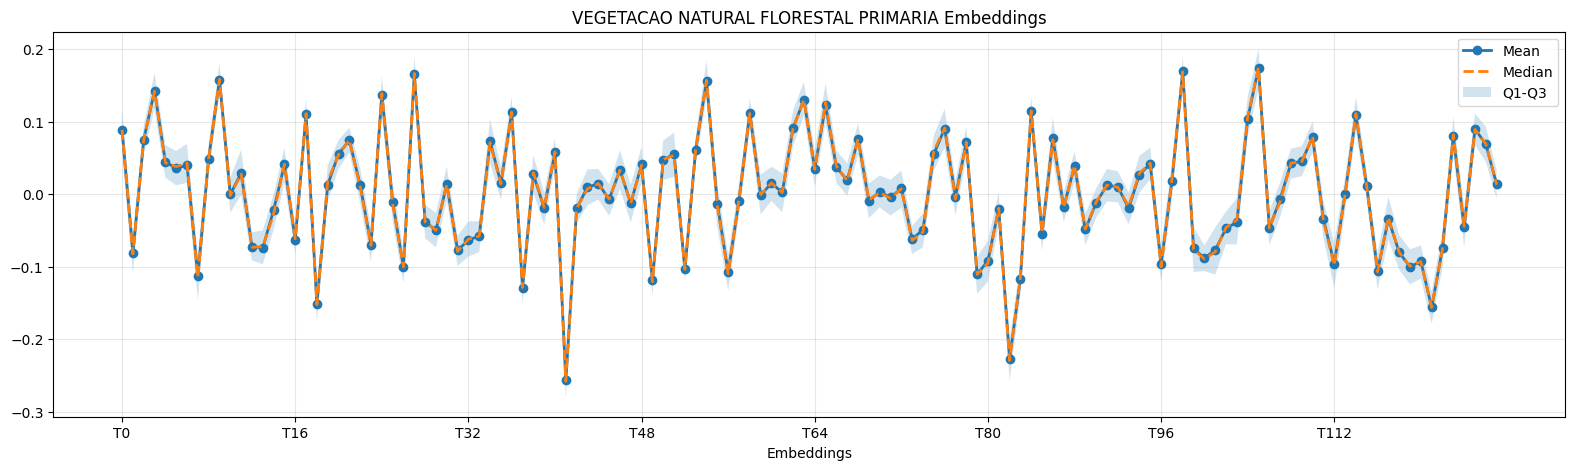

In [38]:
samples_embeddings = samples_roi_tile_2.copy()
labels = set(samples_embeddings["label"])
column_names = [f"T{i}" for i in range(128)]
for label in labels:
    data_ = samples_embeddings[samples_embeddings["label"] == label]
    generatePlotFigPatterns(data_[column_names], label)